In [2]:
# import necessary packages
import cmapPy.pandasGEXpress.GCToo as GCToo
import pandas as pd
from cmapPy.pandasGEXpress.parse import parse
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

## Select only the 978 landmark genes and all the samples that had a high transcriptional response to drug compounds

#### *1. Select the 978 landmark gene ids to extract from .gctx file*

In [3]:
# read gene info from gene_info metadata
file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/GSE70138_Broad_LINCS_gene_info_2017-03-06.txt"
gene_info = pd.read_csv(file_path, sep="\t", dtype=str)
gene_info.head()

,pr_gene_id,pr_gene_symbol,pr_gene_title,pr_is_lm,pr_is_bing
0,780,DDR1,discoidin domain receptor tyrosine kinase 1,1,1
1,7849,PAX8,paired box 8,1,1
2,2978,GUCA1A,guanylate cyclase activator 1A,0,0
3,2049,EPHB3,EPH receptor B3,0,1
4,2101,ESRRA,estrogen related receptor alpha,0,1


In [4]:
# select the ids of only the landmark genes
lm_gene_id = gene_info["pr_gene_id"][gene_info["pr_is_lm"] == "1"]

# check that I have the 978 landmark genes
print(len(lm_gene_id)) 

978


#### *2. Filter out only the trt_cp data using GSE70138_Broad_LINCS_sig_info.txt and save into trt_cps_sig_info.txt with the command line:*
``` bash
grep trt_cp GSE70138_Broad_LINCS_sig_info.txt | cut -f-3,5-8 > trt_cps.txt
head -1 GSE70138_Broad_LINCS_sig_info.txt | cut -f-3,5-8 > column_names_sig_info.txt
cat column_names_sig_info.txt trt_cps.txt > trt_cps_sig_info.txt
rm column_names_sig_info.txt trt_cps.txt
```

#### *3. Extract trt_cps and save as TAS_trt_cps.txt using the following command:*
```bash
grep trt_cp GSE70138_Broad_LINCS_sig_metrics_2017-03-06.txt | cut -f2,5-6,8 > trt_cps.txt
head -1 GSE70138_Broad_LINCS_sig_metrics_2017-03-06.txt | cut -f2,5-6,8 > column_names_sig_metrics.txt
cat column_names_sig_metrics.txt trt_cps.txt > TAS_trt_cps.txt
rm column_names_sig_metrics.txt trt_cps.txt
```

## Select the gene signatures ids of compounds of interest

#### *1. Select all gene signature info with MCF7*

In [5]:
# read the gene signature info
file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/trt_cps_sig_info.txt"
sig_info = pd.read_csv(file_path, sep="\t", dtype=str)
sig_info.set_index("sig_id", inplace=True)

In [6]:
# select only the gene signature ids with MCF7
MCF7_sig_info = sig_info[sig_info['cell_id'] == 'MCF7']
MCF7_sig_info.head()

,pert_id,pert_iname,cell_id,pert_idose,pert_itime,distil_id
sig_id,,,,,,
LJP005_MCF7_24H:A07,BRD-K76908866,CP-724714,MCF7,10.0 um,24 h,LJP005_MCF7_24H_X1_B17:A07|LJP005_MCF7_24H_X2_...
LJP005_MCF7_24H:A08,BRD-K76908866,CP-724714,MCF7,3.33 um,24 h,LJP005_MCF7_24H_X1_B17:A08|LJP005_MCF7_24H_X2_...
LJP005_MCF7_24H:A09,BRD-K76908866,CP-724714,MCF7,1.11 um,24 h,LJP005_MCF7_24H_X1_B17:A09|LJP005_MCF7_24H_X2_...
LJP005_MCF7_24H:A10,BRD-K76908866,CP-724714,MCF7,0.37 um,24 h,LJP005_MCF7_24H_X1_B17:A10|LJP005_MCF7_24H_X2_...
LJP005_MCF7_24H:A11,BRD-K76908866,CP-724714,MCF7,0.12 um,24 h,LJP005_MCF7_24H_X1_B17:A11|LJP005_MCF7_24H_X2_...


#### *2. From these gene signatures, select only those with very high transcriptional responses (TAS > 0.6)*

##### a. Sort TAS scores in descending order and select only those where TAS > 0.6

In [7]:
# read the TAS scores of the gene signatures
file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/TAS_trt_cps.txt"
tas_trt_cps = pd.read_csv(file_path, sep="\t", dtype=str)
tas_trt_cps.set_index('sig_id', inplace=True)
tas_trt_cps.head()

,pert_id,pert_iname,tas
sig_id,,,
REP.A001_A375_24H:A07,BRD-K25114078,aminoguanidine,0.111322
REP.A001_A375_24H:A08,BRD-K25114078,aminoguanidine,0.104451
REP.A001_A375_24H:A09,BRD-K25114078,aminoguanidine,0.113235
REP.A001_A375_24H:A10,BRD-K25114078,aminoguanidine,0.0747183
REP.A001_A375_24H:A11,BRD-K25114078,aminoguanidine,0.107109


In [8]:
# sort the TAS scores in descending order
top_trt_cps = tas_trt_cps.sort_values(by='tas', ascending=False)
top_trt_cps['tas'] = top_trt_cps['tas'].astype(float)

# select only the ones with very high response (TAS > 0.6)
high_tas_trt_cps = top_trt_cps[top_trt_cps['tas'] > 0.6]

# check that the table ends at 0.6
high_tas_trt_cps.tail(10)

,pert_id,pert_iname,tas
sig_id,,,
REP.A023_HT29_24H:H09,BRD-K69776681,volasertib,0.600136
REP.A014_PC3_24H:P13,BRD-K41599323,lonafarnib,0.600136
REP.A002_YAPC_24H:C22,BRD-K50691590,bortezomib,0.600128
REP.A004_PC3_24H:E14,BRD-K21361524,kpt-330,0.600068
LJP007_MCF7_24H:P24,BRD-K42728290,NVP-BGJ398,0.600068
LJP008_NPC_24H:E13,BRD-K54606188,BRD-K54606188,0.600068
REP.A011_A375_24H:J22,BRD-K06858286,cabazitaxel,0.600068
LJP009_PC3_24H:L18,BRD-K78790801,BRD-K78790801,0.600068
REP.A022_A375_24H:P19,BRD-K82746043,navitoclax,0.600017


##### b. Select the MCF7 sig ids that had a TAS score > 0.6

In [9]:
# initialize a variable to store the MCF7 sig ids with high TAS scores
high_tas_sig_ids = []

# look through the high_tas_trt_cps
# if the sig_id is in the MCF7_sig_info, 
# then select this sig_id
for sig_id in high_tas_trt_cps.index:
    if sig_id in MCF7_sig_info.index:
        high_tas_sig_ids.append(sig_id)

# select all the MCF7_sig_info with all these sig ids
high_tas_sig_info = MCF7_sig_info.loc[high_tas_sig_ids]

##### c. Check that high_tas_sig_info has high TAS scores

In [10]:
# print out the first 5 TAS scores
high_tas_trt_cps.loc[high_tas_sig_ids].head()

,pert_id,pert_iname,tas
sig_id,,,
REP.A025_MCF7_24H:E04,BRD-K99475619,genz-644282,0.844651
REP.A020_MCF7_24H:O01,BRD-K60230970,MG-132,0.837942
REP.A022_MCF7_24H:O01,BRD-K60230970,MG-132,0.837393
REP.A013_MCF7_24H:D08,BRD-K37890730,camptothecin,0.837161
REP.A022_MCF7_24H:E01,BRD-K68747584,pf-03814735,0.833992


In [11]:
# check that they match the sig_ids in the high_tas_sig_info table
high_tas_sig_info.head()

,pert_id,pert_iname,cell_id,pert_idose,pert_itime,distil_id
sig_id,,,,,,
REP.A025_MCF7_24H:E04,BRD-K99475619,genz-644282,MCF7,0.37 um,24 h,REP.A025_MCF7_24H_X1_B23:E04|REP.A025_MCF7_24H...
REP.A020_MCF7_24H:O01,BRD-K60230970,MG-132,MCF7,20.0 um,24 h,REP.A020_MCF7_24H_X1_B23:O01|REP.A020_MCF7_24H...
REP.A022_MCF7_24H:O01,BRD-K60230970,MG-132,MCF7,20.0 um,24 h,REP.A022_MCF7_24H_X1_B23:O01|REP.A022_MCF7_24H...
REP.A013_MCF7_24H:D08,BRD-K37890730,camptothecin,MCF7,3.33 um,24 h,REP.A013_MCF7_24H_X1_B24:D08|REP.A013_MCF7_24H...
REP.A022_MCF7_24H:E01,BRD-K68747584,PF-03814735,MCF7,10.0 um,24 h,REP.A022_MCF7_24H_X1_B23:E01|REP.A022_MCF7_24H...


#### *3. Select 3 compounds to compare to each other*

In [12]:
# count the total number of unique compounds 
len(high_tas_sig_info['pert_iname'].unique())

157

In [13]:
# show the number of samples available for each of the top 10 compounds
high_tas_sig_info['pert_iname'].value_counts().head(20)

bortezomib                   341
MG-132                       332
CGP-60474                     28
OTS-167                       11
alvocidib                     10
dinaciclib                    10
AT-7519                        8
mitoxantrone                   7
dolastatin-10                  6
delanzomib                     6
camptothecin                   6
genz-644282                    6
podophyllotoxin                6
bruceantin                     6
JNJ-26481585                   6
phorbol-myristate-acetate      6
WZ-3105                        6
homoharringtonine              6
dacinostat                     6
combretastatin-A-4             6
Name: pert_iname, dtype: int64

*From this list of sig ids and a quick google search, I chose to compare gene signature ids of alvocidib & camptothecin (leukemia) vs combretastatin-A-4.*

In [14]:
trt_cps = ['alvocidib', 'camptothecin', 'combretastatin-A-4']

In [15]:
# select the sig_info for these three compounds
test_cps_sig_info = high_tas_sig_info[high_tas_sig_info['pert_iname'].isin(trt_cps)]
test_cps_sig_info

,pert_id,pert_iname,cell_id,pert_idose,pert_itime,distil_id
sig_id,,,,,,
REP.A013_MCF7_24H:D08,BRD-K37890730,camptothecin,MCF7,3.33 um,24 h,REP.A013_MCF7_24H_X1_B24:D08|REP.A013_MCF7_24H...
REP.A013_MCF7_24H:D07,BRD-K37890730,camptothecin,MCF7,10.0 um,24 h,REP.A013_MCF7_24H_X1_B24:D07|REP.A013_MCF7_24H...
REP.A013_MCF7_24H:D09,BRD-K37890730,camptothecin,MCF7,1.11 um,24 h,REP.A013_MCF7_24H_X1_B24:D09|REP.A013_MCF7_24H...
REP.A026_MCF7_24H:B19,BRD-K87909389,alvocidib,MCF7,10.0 um,24 h,REP.A026_MCF7_24H_X1_B25:B19|REP.A026_MCF7_24H...
LJP006_MCF7_24H:A15,BRD-K87909389,alvocidib,MCF7,1.11 um,24 h,LJP006_MCF7_24H_X1_B17:A15|LJP006_MCF7_24H_X2_...
REP.A026_MCF7_24H:B22,BRD-K87909389,alvocidib,MCF7,0.37 um,24 h,REP.A026_MCF7_24H_X1_B25:B22|REP.A026_MCF7_24H...
LJP006_MCF7_24H:A16,BRD-K87909389,alvocidib,MCF7,0.37 um,24 h,LJP006_MCF7_24H_X1_B17:A16|LJP006_MCF7_24H_X2_...
LJP006_MCF7_24H:A13,BRD-K87909389,alvocidib,MCF7,10.0 um,24 h,LJP006_MCF7_24H_X1_B17:A13|LJP006_MCF7_24H_X2_...
REP.A013_MCF7_24H:D10,BRD-K37890730,camptothecin,MCF7,0.37 um,24 h,REP.A013_MCF7_24H_X1_B24:D10|REP.A013_MCF7_24H...


In [18]:
# store the sig ids of these compounds
test_cps_sig_ids = test_cps_sig_info.index

#### *4. Select the gene signatures for selected compounds*

In [19]:
# defining function to select relevant data at one dose
def select_dose(sig_info, dose):
    select_dose_sig_info = sig_info[sig_info["pert_idose"] == dose]
    return select_dose_sig_info

##### a. Test to see what data looks like at one dose (at 0.04 um)

In [20]:
# select only 0.04 um dose to see what the data looks like
dose_sig_info = select_dose(test_cps_sig_info, '1.11 um')
dose_sig_info

,pert_id,pert_iname,cell_id,pert_idose,pert_itime,distil_id
sig_id,,,,,,
REP.A013_MCF7_24H:D09,BRD-K37890730,camptothecin,MCF7,1.11 um,24 h,REP.A013_MCF7_24H_X1_B24:D09|REP.A013_MCF7_24H...
LJP006_MCF7_24H:A15,BRD-K87909389,alvocidib,MCF7,1.11 um,24 h,LJP006_MCF7_24H_X1_B17:A15|LJP006_MCF7_24H_X2_...
REP.A026_MCF7_24H:B21,BRD-K87909389,alvocidib,MCF7,1.11 um,24 h,REP.A026_MCF7_24H_X1_B25:B21|REP.A026_MCF7_24H...
REP.A015_MCF7_24H:O09,BRD-K61195623,combretastatin-A-4,MCF7,1.11 um,24 h,REP.A015_MCF7_24H_X2_B23:O09|REP.A015_MCF7_24H...


All gene signatures measured after 24 hrs, so there is no need to select one time point to further simplify the data.

##### b. create separate datasets at each dosage

In [21]:
# obtain all the different dosages
pert_idoses = test_cps_sig_info["pert_idose"].unique()

# initialize a list to store all the gene signatures and sig info for each dose in pert_idose
sig_infos = []

In [22]:
# read the LINCS Level 5 dataset
file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/LINCS_dataset.gctx"

# separate gene signatures by each dose in pert_idose
for dose in pert_idoses:
    # select gene signatures of one dose
    dose_sig_info = select_dose(test_cps_sig_info, dose)
    
    # select the gene signature ids
    dose_sig_ids = dose_sig_info.index
    
    # select only the landmark genes of drug compounds of interest
    dose_gene_sigs = parse(file_path, rid=lm_gene_id, cid=dose_sig_ids)
    
    # create a new GCTOO object that contains the sig_info as the columns and gene_sigs as rows
    sig_info = GCToo.GCToo(data_df=dose_gene_sigs.data_df.copy(), 
                                              row_metadata_df=dose_gene_sigs.row_metadata_df.copy(), 
                                              col_metadata_df=dose_sig_info, 
                                             make_multiindex=True)
    
    # store sig_info
    sig_infos.append(sig_info)

In [77]:
# snapshot of what each dataset looks like for each dose
sig_infos[1].multi_index_df[:5]

pert_id                                                                             BRD-K37890730  \
pert_iname                                                                           camptothecin   
cell_id                                                                                      MCF7   
pert_idose                                                                                10.0 um   
pert_itime                                                                                   24 h   
distil_id  REP.A013_MCF7_24H_X1_B24:D07|REP.A013_MCF7_24H_X2_B22:D07|REP.A013_MCF7_24H_X3_B22:D07   
cid                                                                         REP.A013_MCF7_24H:D07   
rid                                                                                                 
0                                                    1.790300                                       
1                                                    5.365927                                       
2                                                    1.333085                                       
3                                                    1.763183                                       
4                                                   -0.993653                                       

pert_id                                                                             BRD-K61195623  \
pert_iname                                                                     combretastatin-A-4   
cell_id                                                                                      MCF7   
pert_idose                                                                                10.0 um   
pert_itime                                                                                   24 h   
distil_id  REP.A015_MCF7_24H_X1_B23:O07|REP.A015_MCF7_24H_X2_B23:O07|REP.A015_MCF7_24H_X3_B23:O07   
cid                                                                         REP.A015_MCF7_24H:O07   
rid                                                                                                 
0                                                   -0.422348                                       
1                                                   -1.134135                                       
2                                                   -0.916518                                       
3                                                    0.132876                                       
4                                                    4.297299                                       

pert_id                                                                             BRD-K87909389  \
pert_iname                                                                              alvocidib   
cell_id                                                                                      MCF7   
pert_idose                                                                                10.0 um   
pert_itime                                                                                   24 h   
distil_id  REP.A026_MCF7_24H_X1_B25:B19|REP.A026_MCF7_24H_X2_B25:B19|REP.A026_MCF7_24H_X3_B25:B19   
cid                                                                         REP.A026_MCF7_24H:B19   
rid                                                                                                 
0                                                   -0.824531                                       
1                                                    2.019873                                       
2                                                    1.206271                                       
3                                                   -0.014839                                       
4                                                   -1.163775                                       

pert_id                                                   

Based on the previous two data tables, it seems like there are 2 gene signatures for alvocidib. Can simplify and just select the LJP006_MCF7_24H:A14 one first and comparing with the other 2 drugs.

## Perform Spearman Correlations

In [63]:
# function to create a scatter plot for each drug dosage comparing 2 drug compounds
def spearman_correlation(sig_infos, col1_idx, col2_idx):
    for dose_sig_info in sig_infos:
        plt.figure()
        # make a scatterplot 
        sns.scatterplot(
            x = dose_sig_info.data_df.iloc[:, col1_idx],
            y = dose_sig_info.data_df.iloc[:, col2_idx]
        )
        plt.xlabel(dose_sig_info.col_metadata_df.iloc[col1_idx].pert_iname)
        plt.ylabel(dose_sig_info.col_metadata_df.iloc[col2_idx].pert_iname)
        plt.title(dose_sig_info.col_metadata_df.iloc[col1_idx].pert_idose)
        plt.show()

        # perform a spearman correlation
        print(stats.spearmanr(dose_sig_info.data_df.iloc[:, col1_idx], dose_sig_info.data_df.iloc [:,col2_idx]))

#### *1. Compare the gene signatures of similar drugs targeting the same disease to each other*

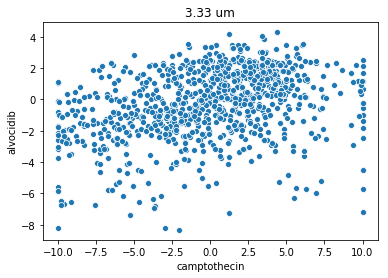

SpearmanrResult(correlation=0.37604236254205664, pvalue=3.2902061524283375e-34)


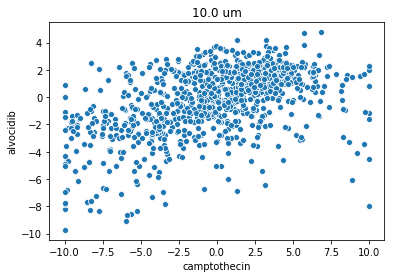

SpearmanrResult(correlation=0.505353910185574, pvalue=1.605544425387621e-64)


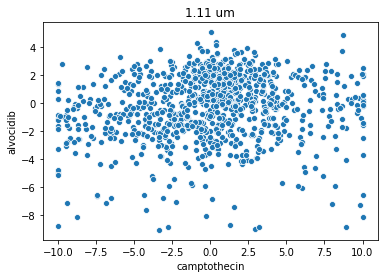

SpearmanrResult(correlation=0.16917087482388296, pvalue=1.0256616066933548e-07)


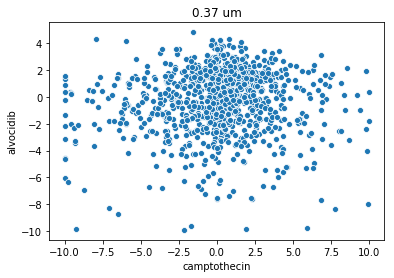

SpearmanrResult(correlation=0.07716717298953554, pvalue=0.015788770388884273)


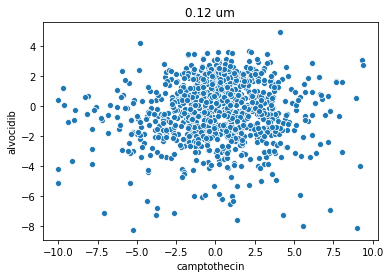

SpearmanrResult(correlation=0.06430052824820837, pvalue=0.044391098827664455)


In [74]:
# compare campthothecin (1st column) & alvocidib (4th column)
# no 0.04 um dose is available for alvocidib so removing last dose
spearman_correlation(sig_infos[:-1], 0, 3)

#### *2. Compare the gene signatures of these drugs to the gene signature of another drug targeting a different disease*

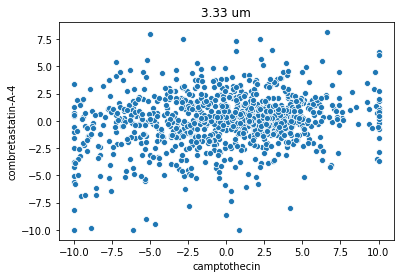

SpearmanrResult(correlation=0.16254314369371206, pvalue=3.209110743439799e-07)


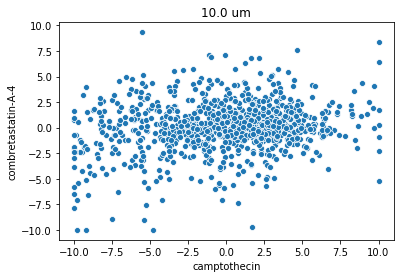

SpearmanrResult(correlation=0.1136207603176445, pvalue=0.0003704992263863734)


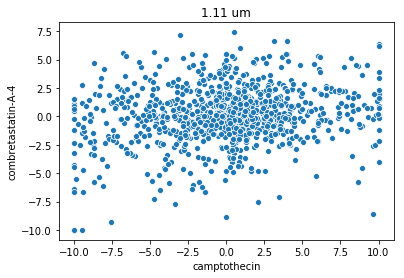

SpearmanrResult(correlation=0.1501914111289535, pvalue=2.3851141834707696e-06)


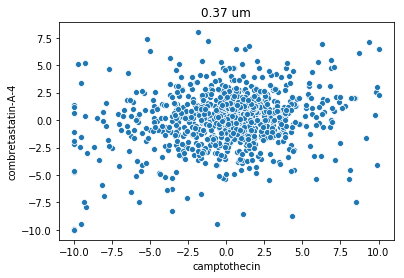

SpearmanrResult(correlation=0.14924446632538585, pvalue=2.7638866477524688e-06)


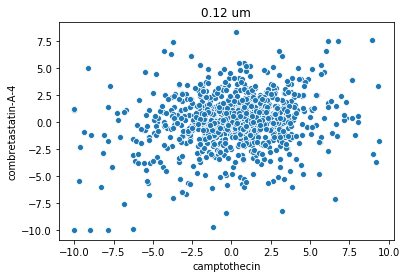

SpearmanrResult(correlation=0.13105012376374164, pvalue=3.9424125473628836e-05)


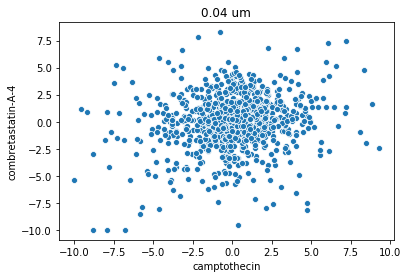

SpearmanrResult(correlation=0.13056541812977707, pvalue=4.21271402365544e-05)


In [76]:
# compare camptothecin (1st column) & combretastatin-A-4 (2nd column)
spearman_correlation(sig_infos, 0, 1)

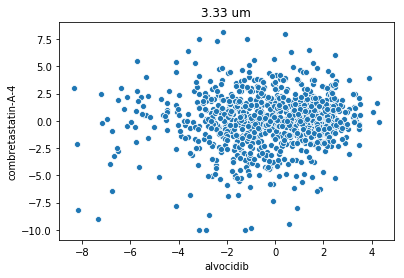

SpearmanrResult(correlation=0.0537298111581805, pvalue=0.09308264227621671)


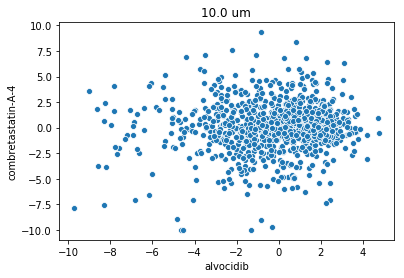

SpearmanrResult(correlation=0.021941881956126248, pvalue=0.49309579839439543)


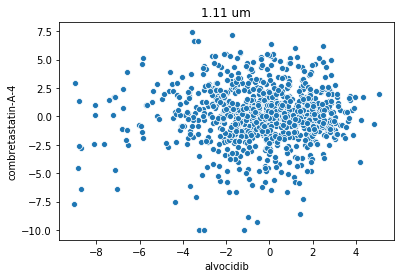

SpearmanrResult(correlation=-0.0322494169759213, pvalue=0.31369070678395833)


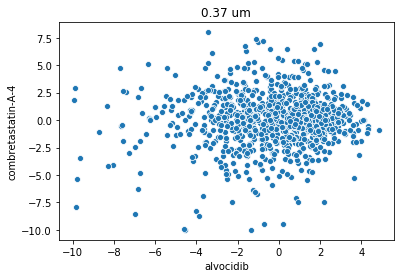

SpearmanrResult(correlation=0.018192915900996542, pvalue=0.5698541409983485)


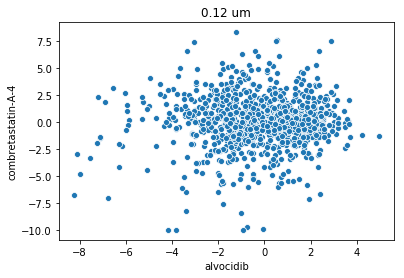

SpearmanrResult(correlation=-0.010617482747064377, pvalue=0.7401723199154935)


In [78]:
# compare alvocidib (4th column) & combretastatin-A-4 (2nd column)
# no 0.04 um dose is available for alvocidib so removing last dose
spearman_correlation(sig_infos[:-1], 3, 1)